## pairwise alignment corona

In [10]:
import pandas as pd
from Bio import pairwise2

# Lies deine Tabelle ein
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Wir nehmen z.B. die Spalte 'CDR_H1' zum pairwise Vergleichen
cdr_column = 'CDR_H1'

# Optional: Filtere leere oder fehlende Sequenzen raus
data = data[data[cdr_column].notnull()]

# Liste für Scores
scores = []

# Alle pairwise alignments innerhalb der CDR_H1-Spalte
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Hier wird der Score sofort in eine Datei geschrieben:
            with open('scores_CDR_H1.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")



In [11]:
import numpy as np

scores = []

# Read the file and extract scores
cdr_column = 'CDR_H1'  # Use the same column name as before

with open(f'scores_{cdr_column}.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        score = float(parts[2])
        scores.append(score)

# Calculate average
if scores:
    average_score = np.mean(scores)
    print(f"Average alignment score for {cdr_column}: {average_score:.2f}")
else:
    print("No scores found.")



Average alignment score for CDR_H1: 3.72


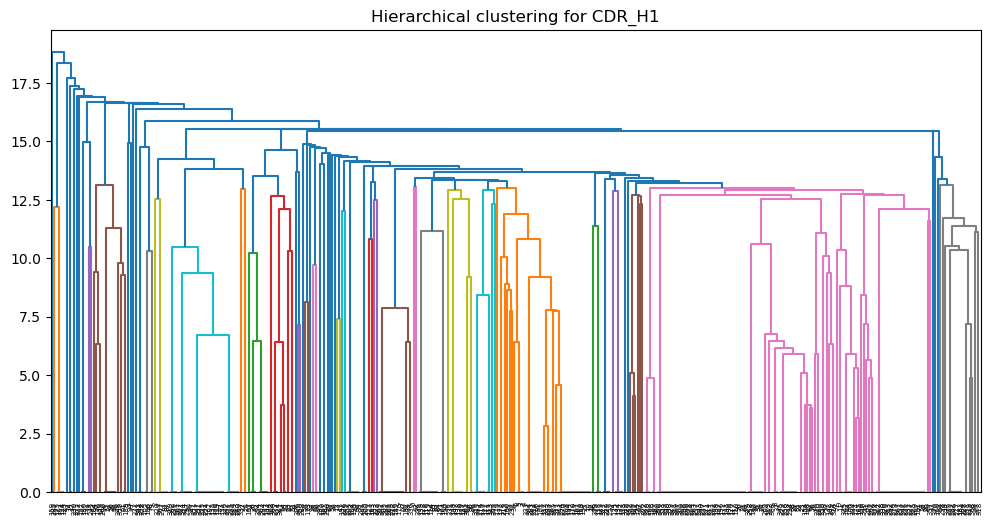

In [13]:
import pandas as pd
import numpy as np
from Bio import pairwise2
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load your table
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

cdr_column = 'CDR_H1'
data = data[data[cdr_column].notnull()]
data = data.reset_index(drop=True)  # reset indices after filtering

num_sequences = len(data)
# Initialize a similarity matrix
similarity_matrix = np.zeros((num_sequences, num_sequences))

# Compute pairwise alignment scores
for i in range(num_sequences):
    for j in range(i, num_sequences):
        seq1 = data.loc[i, cdr_column]
        seq2 = data.loc[j, cdr_column]
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]
            similarity_matrix[i, j] = score
            similarity_matrix[j, i] = score  # matrix is symmetric

# Now turn similarity into distance (simple way: max_score - score)
max_score = np.max(similarity_matrix)
distance_matrix = max_score - similarity_matrix

# Perform hierarchical clustering
linked = linkage(distance_matrix, 'single')  # you can also try 'complete', 'average', etc.

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=data.index)
plt.title(f"Hierarchical clustering for {cdr_column}")
plt.show()


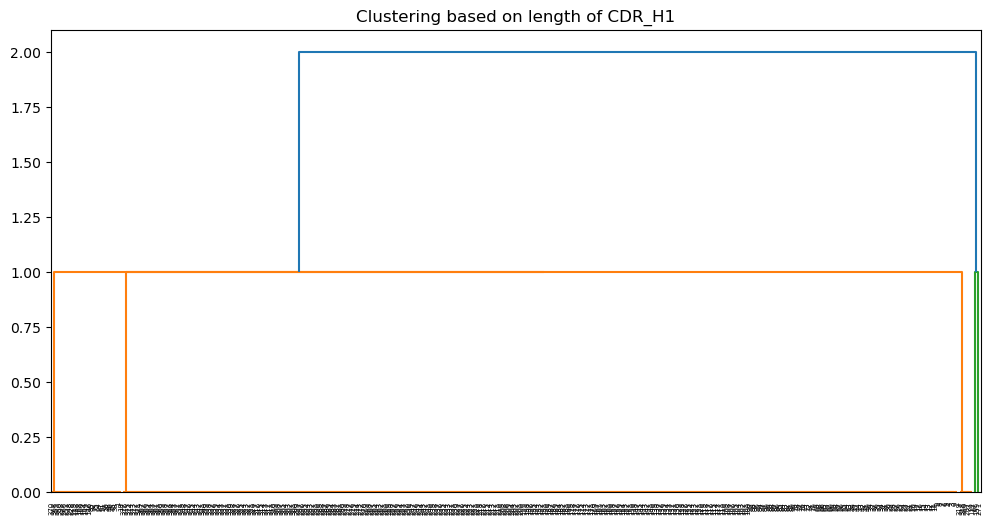

In [17]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

cdr_column = 'CDR_H1'
data = data[data[cdr_column].notnull()]
data = data.reset_index(drop=True)

# Extract sequence lengths
data['length'] = data[cdr_column].apply(len)

# You can also use other features later (e.g. AA composition etc.)

# Reshape into correct form for clustering
lengths = data['length'].values.reshape(-1, 1)

# Hierarchical clustering
linked = linkage(lengths, 'single')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=data.index)
plt.title(f"Clustering based on length of {cdr_column}")
plt.show()

In [14]:
import pandas as pd
from Bio import pairwise2

# Lies deine Tabelle ein
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Wir nehmen z.B. die Spalte 'CDR_H2' zum pairwise Vergleichen
cdr_column = 'CDR_H2'

# Optional: Filtere leere oder fehlende Sequenzen raus
data = data[data[cdr_column].notnull()]

# Liste für Scores
scores = []

# Alle pairwise alignments innerhalb der CDR_H2-Spalte
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Hier wird der Score sofort in eine Datei geschrieben:
            with open('scores_CDR_H2.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")


In [18]:
import numpy as np

scores = []

# Read the file and extract scores
cdr_column = 'CDR_H2'  # Use the same column name as before

with open(f'scores_{cdr_column}.txt', 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        score = float(parts[2])
        scores.append(score)

# Calculate average
if scores:
    average_score = np.mean(scores)
    print(f"Average alignment score for {cdr_column}: {average_score:.2f}")
else:
    print("No scores found.")


Average alignment score for CDR_H2: 2.24


In [16]:
import pandas as pd
from Bio import pairwise2

# Load your table
data = pd.read_csv('sars_cov2_cdr_seq.tsv', sep='\t')

# Select the CDR column you want to analyze
cdr_column = 'CDR_H3'  # Now we analyze CDR_H3

# Filter out missing or empty sequences
data = data[data[cdr_column].notnull()]

# List to store alignment scores (optional)
scores = []

# Perform pairwise alignments within the CDR_H3 column
for i in range(len(data)):
    for j in range(i+1, len(data)):
        seq1 = data.iloc[i][cdr_column]
        seq2 = data.iloc[j][cdr_column]
        
        if isinstance(seq1, str) and isinstance(seq2, str):
            alignments = pairwise2.align.globalxx(seq1, seq2)
            score = alignments[0][2]  # alignment score
            scores.append(score)
            
            # Save the score directly into a file
            with open('scores_CDR_H3.txt', 'a') as f:
                f.write(f"{i},{j},{score}\n")


#### hierchical clustering

In [7]:
%pip install seaborn scipy
import seaborn as sns
import scipy.cluster.hierarchy as sch

sns.clustermap(similarity_matrix, cmap='viridis')


   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   ------ --------------------------------- 6.3/41.0 MB 18.4 MB/s eta 0:00:02
   ----------- ---------------------------- 11.8/41.0 MB 17.6 MB/s eta 0:00:02
   ------------------- -------------------- 20.2/41.0 MB 18.0 MB/s eta 0:00:02
   ----------------------------- ---------- 29.9/41.0 MB 16.6 MB/s eta 0:00:01
   ---------------------------------- ----- 35.7/41.0 MB 17.4 MB/s eta 0:00:01
   -------------------------------------- - 39.3/41.0 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------  40.9/41.0 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 41.0/41.0 MB 15.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


NameError: name 'similarity_matrix' is not defined

#### Dimensionality Reduction 

In [8]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
dissimilarity = 1 - (similarity_matrix / np.max(similarity_matrix))  # Abstand statt Ähnlichkeit
coords = mds.fit_transform(dissimilarity)

plt.scatter(coords[:, 0], coords[:, 1])
plt.title('MDS of CDR_H1 sequences')
plt.show()


ModuleNotFoundError: No module named 'sklearn'